# Data & AI Governance

A company builds a hiring model. It performs great in testing — strong accuracy, a clean pilot. Six months after launch, someone notices it has been quietly rejecting applicants from a specific group at a much higher rate than everyone else. Nobody can say who approved the model, what data trained it, or whether anyone checked for this before it shipped.

That is not a technical failure. That is a **governance** failure — there was no process in place that would have caught it.

This tutorial is about that process: the paperwork, checkpoints, and legal requirements that make sure someone actually looks *before* a model goes live, and that what happened can be traced *after*. It builds on the technical tools covered elsewhere in this repo — fairness metrics (`fairness-group-vs-individual`), coverage guarantees (`conformal-prediction`), explanations (`shap-lime-explainability`), counterfactual fairness (`counterfactual-fairness`) — and asks the next question: **who checks these numbers, when, and what happens if a model fails the check?**

By the end of this tutorial you will be able to:

- Write a real **Model Card** and **Datasheet** for a model/dataset pair.
- State precisely what the **EU AI Act** and **GDPR Article 22** do and do not require (the popular "right to explanation" story is not quite right — more on that below).
- Build a real, runnable **governance gate**: a pre-deployment check that blocks or approves a trained model against a stated fairness policy.

**Prerequisites:** the `fairness-group-vs-individual` tutorial in this domain (we reuse its dataset and metric definitions), basic pandas/sklearn.


## The idea, intuitively

Strip away the legal citations and governance comes down to three plain-English ideas.

**1. Data lineage — can you trace what happened?**

If a model behaves badly, you need to be able to answer "what data trained this, and what was done to it?" **Data lineage** is just a record of that: which raw rows went in, what filtering and cleaning happened, and in what order. Without it, you cannot reproduce the model, defend it to a regulator, or even confirm a reported bug is real.

**2. Model documentation — is there something a human can actually read?**

A **Model Card** is a short, standardized document that ships with a trained model: what it does, what data trained it, how it performs across different groups, and — critically — what it should *not* be used for. A **Datasheet** does the same job for a dataset. Neither one certifies that a model is safe; they are a **disclosure mechanism** — a form that forces someone to write the answers down instead of skipping the question.

Here is what a few real, filled-in Model Card fields look like (a slice of the full card built in Section 3 — not the whole thing):

> **Primary intended use:** Educational demonstration of a governance gate applied to a recidivism-risk classifier.
> **Out-of-scope use:** Any real pretrial, sentencing, or parole decision.
> **Metrics reported:** accuracy = 0.669, demographic parity difference = 0.223.

**3. A governance gate — does anyone actually check before it ships?**

This is the part that makes the other two matter. A **governance gate** is a checkpoint, run *before* deployment, that compares a model's real fairness numbers against thresholds the organization committed to *in advance*. If the model fails, it does not ship — unless someone with real authority signs off on an explicit, documented exception. Reduced to its simplest form, using this tutorial's own real numbers (Section 3 computes these properly; here they are just hard-coded to show the shape of the check):


In [1]:
# The governance-gate idea, stripped to five lines.
# (0.223 and the 0.10 policy are this tutorial's real, later-computed numbers -- see Section 3.3.)
policy_max_gap = 0.10                    # decided BEFORE looking at the model
measured_gap = 0.223                     # real demographic parity difference, computed in Section 3.3

if measured_gap > policy_max_gap:
    print(f"FAIL: fairness gap {measured_gap:.3f} exceeds policy max {policy_max_gap:.2f} -- do not deploy")
else:
    print(f"PASS: fairness gap {measured_gap:.3f} within policy max {policy_max_gap:.2f}")


FAIL: fairness gap 0.223 exceeds policy max 0.10 -- do not deploy


That five-line check is the entire idea of a governance gate: a threshold fixed in advance, a real number measured after training, and a decision that follows automatically from the comparison. Section 3.6 builds the real version — it also checks documentation completeness and lineage, not just the fairness numbers, and it runs against this notebook's actual trained classifier.

**That's the whole idea.** Governance is the paperwork and checkpoints that make sure someone looks *before* a model ships, and that what happened can be traced *after*. The rest of this notebook covers the real frameworks (EU AI Act, GDPR, NIST) precisely, and builds real governance artifacts — a real Model Card, a real Datasheet, a real gate — for an actual trained model. Read on for the how and why, or skip ahead to **Section 3, Implementation**, to see it applied.


## 1. Going deeper: the real frameworks and their actual requirements

*The section above gave the intuition. Everything below is the precise, citation-backed version: the actual required sections of a Model Card and Datasheet, and the actual regulatory text of the EU AI Act, GDPR, and the NIST AI RMF -- read this if you want the "why" behind the artifacts Section 3 builds, or want to cite this correctly. If you just want to see the artifacts applied to a real model, skip ahead to* **Section 3, Implementation**.

### 1.1 Data lineage and provenance

**Provenance** is the record of where a piece of data came from and what
was done to it; **lineage** is the end-to-end graph of that provenance
across a pipeline — every transformation from raw source to the feature
matrix a model was trained on. The standard formal model for provenance is
the W3C's **PROV Data Model** (PROV-DM, 2013), which represents provenance
as a graph over three core types:

- **Entities** — pieces of data (a raw file, a cleaned table, a trained
  model, a feature column).
- **Activities** — processes that act on entities (a filtering step, a
  join, a training run).
- **Agents** — who or what is responsible (a person, an organization, a
  pipeline/software component).

with relations `wasGeneratedBy`, `used`, `wasDerivedFrom`, `wasAssociatedWith`
connecting them. A lineage record for a trained model is, formally, the
transitive closure of `wasDerivedFrom` edges back from the model entity to
every raw data entity it depends on.

**Why this matters for responsible data science specifically, not just data
engineering:** every claim this repo's other tutorials make — a fairness
gap of 0.17, a conformal coverage guarantee of 90%, a SHAP attribution — is
a claim about a *specific* trained model on a *specific* version of a
dataset. If you cannot reproduce which rows were included, which filtering
was applied (recall the fairness tutorial's COMPAS screening-window filter),
and which code version produced the features, you cannot audit *or defend*
any of those downstream claims. An unauditable pipeline makes every fairness
or privacy claim about it unfalsifiable — which is precisely the failure
mode governance is meant to close. In practice, this is implemented with
lineage-tracking tools (e.g. OpenLineage, MLflow's run tracking, or simply
a disciplined append-only log of transformation steps), which is what we
build a minimal version of in Section 3.

### 1.2 Model documentation: Model Cards

**Model Cards** (Mitchell, Wu, Zaldivar, Barnes, Vasserman, Hutchinson,
Spitzer, Raji, Gebru — Google, FAT* 2019, "Model Cards for Model
Reporting") are a standardized short document accompanying a trained model.
The paper specifies these required sections:

1. **Model Details** — basic information: developing organization/person,
   model date, version, model type, training algorithms and parameters,
   paper/citation, license, contact.
2. **Intended Use** — primary intended uses, primary intended users, and
   explicitly out-of-scope uses.
3. **Factors** — relevant demographic/environmental/technical factors the
   model's performance may vary across (groups, instrumentation, domains).
4. **Metrics** — the performance measures reported, why they were chosen,
   and how variation was measured (e.g. confidence intervals).
5. **Evaluation Data** — datasets used to evaluate, why, preprocessing.
6. **Training Data** — ideally mirrors Evaluation Data; where infeasible,
   minimally the distribution over relevant factors.
7. **Quantitative Analyses** — unitary results (per-factor) *and*
   intersectional results (combinations of factors), since a model can be
   fair marginally on race and marginally on sex while failing on their
   intersection (a limitation flagged explicitly in the
   `fairness-group-vs-individual` tutorial).
8. **Ethical Considerations** — sensitive data used, risks/harms identified,
   mitigations attempted.
9. **Caveats and Recommendations** — additional testing needed, groups that
   may require extra evaluation, recommendations for downstream use.

The point of the format is that it is *short, standardized, and asks
specifically for negative information* (out-of-scope uses, caveats) that
model developers otherwise omit. It does not certify a model is fair or
safe — it is a **disclosure mechanism**, not a safety guarantee.

### 1.3 Model documentation: Datasheets for Datasets

**Datasheets for Datasets** (Gebru, Morgenstern, Vecchione, Vaughan,
Wallach, Daumé III, Crawford — CACM 2021, originally proposed 2018) apply
the same idea to the dataset a model is trained or evaluated on, modeled
explicitly on the electronics industry's datasheets for components. The
paper organizes required questions around the dataset's lifecycle:

1. **Motivation** — why was the dataset created, who created it, who funded
   it.
2. **Composition** — what do the instances represent, how many are there,
   is there a label/target, is any information missing and why, are there
   errors/noise/redundancies, does it relate to or rely on external
   resources, does it contain confidential or offensive/sensitive content.
3. **Collection Process** — how was each instance acquired, what was the
   sampling strategy, who was involved in collection, over what timeframe,
   was there ethical review.
4. **Preprocessing/Cleaning/Labeling** — what was done, is the raw data
   also available, is the software used available.
5. **Uses** — what other tasks could the dataset be used for, are there
   risks/harms that using it might cause for future uses, are there tasks
   it **should not** be used for.
6. **Distribution** — how will it be distributed, under what license, are
   there IP/export restrictions.
7. **Maintenance** — who maintains it, how to contact them, will it be
   updated, are older versions retained.

The "Uses" section's explicit **should-not-be-used-for** question is the
one most often skipped in practice, and is exactly the question COMPAS-style
datasets raise: a dataset of arrest records reflects *policing patterns*,
not an unbiased sample of *offending*, which is a documented reason it
should not be treated as ground truth for "criminality" in general (see
Section 6, and Barocas, Hardt & Narayanan 2023 for the general argument that
measurement bias of this kind is a dataset-level, not model-level, problem).

### 1.4 Regulatory frameworks

Model Cards and Datasheets are voluntary industry norms. The following
frameworks make (parts of) this documentation and process **legally
required or at least legally consequential**, and each has real scope
limits that are commonly misstated — precision matters here.

#### 1.4.1 The EU AI Act (Regulation (EU) 2024/1689)

The AI Act (entered into force August 2024, phased application through
2027) regulates AI systems by a **four-tier risk classification** (Titles
II–IV):

- **Unacceptable risk — banned outright (Article 5).** Examples with
  citations to the actual prohibited practices: social scoring by public
  authorities; real-time remote biometric identification in public spaces
  for law enforcement (narrow exceptions apply); AI that manipulates
  behavior via subliminal/deceptive techniques causing significant harm;
  **individual risk assessment to predict the risk of a person committing a
  criminal offence based *solely* on profiling or personality-trait
  assessment** (predictive policing of *individuals* absent objective,
  verifiable facts directly linked to a criminal activity); untargeted
  scraping of facial images to build facial-recognition databases; emotion
  recognition in the workplace/education (narrow exceptions).
- **High risk (Title III, Annex III) — permitted, but under heavy
  obligation.** Annex III enumerates the categories, including: biometric
  identification and categorization; management of critical infrastructure;
  education (exam scoring, admissions); employment (recruitment, worker
  monitoring/evaluation); access to essential private and public services
  (credit scoring, insurance risk pricing, eligibility for public
  benefits); and — directly relevant to this tutorial's worked example —
  **Annex III point 6(d): AI systems intended to be used by or on behalf of
  law enforcement authorities to assess the risk of a natural person for
  offending or reoffending**, i.e. exactly the COMPAS use case, *once it
  goes beyond the solely-profiling-based prediction banned under Article 5*.
  High-risk systems carry concrete obligations, each tied to a specific
  Article: a **risk management system** across the whole lifecycle (Art. 9);
  **data governance** requiring training/validation/testing data to be
  relevant, representative, and examined for bias (Art. 10 — this is the
  Article that most directly operationalizes the Datasheets idea into law);
  **technical documentation** before market placement (Art. 11, Annex IV —
  this is the Article that most directly operationalizes the Model Cards
  idea into law); **record-keeping/automatic logging** (Art. 12);
  **transparency to deployers** (Art. 13); **human oversight** designed
  into the system (Art. 14); **accuracy, robustness, and cybersecurity**
  (Art. 15); and a **conformity assessment** before deployment (Art. 43),
  plus registration in an EU public database (Art. 71).
- **Limited risk — transparency obligations only (Article 50).** E.g.
  chatbots must disclose they are AI; deepfakes and AI-generated content
  must be labeled; emotion-recognition and biometric-categorization systems
  must inform the people subject to them. No conformity assessment or risk
  management system required.
- **Minimal risk — unregulated by the Act.** E.g. spam filters,
  AI-enabled video game NPCs, most recommender-system personalization. The
  large majority of deployed AI systems fall here.

#### 1.4.2 GDPR Article 22 — narrower than commonly claimed

GDPR **Article 22(1)** states: *"The data subject shall have the right not
to be subject to a decision based solely on automated processing, including
profiling, which produces legal effects concerning him or her or similarly
significantly affects him or her."* Three exceptions in Art. 22(2) allow
solely-automated decisions anyway: (a) necessary for a contract, (b)
authorized by Union/Member State law with safeguards, (c) explicit consent
— and where (a) or (c) apply, Art. 22(3) requires only narrow safeguards:
the right to obtain **human intervention**, to **express one's point of
view**, and to **contest the decision**.

This is popularly described as a GDPR "right to explanation," but
**Wachter, Mittelstadt & Floridi (2017)**, in *"Why a Right to Explanation
of Automated Decision-Making Does Not Exist in the General Data Protection
Regulation"* (International Data Privacy Law), argue this framing overstates
what the operative Articles actually grant:

- The phrase "right to an explanation" of a *specific decision* appears
  only in **Recital 71**, a non-binding interpretive recital, not in the
  binding Articles themselves.
- The binding information duties (Articles 13(2)(f), 14(2)(g), 15(1)(h))
  require only "meaningful information about the logic involved" and "the
  significance and envisaged consequences" — this is most plausibly an
  **ex-ante** disclosure about the system in general (a "right to be
  informed"), not an **ex-post**, decision-specific explanation of *why you
  personally* got the outcome you got.
- Article 22 itself applies only to decisions that are (a) **solely**
  automated (a human "in the loop" who exercises real judgment removes the
  protection, and the bar for what counts as genuine human involvement is
  itself contested) and (b) produce **legal or similarly significant**
  effects — a threshold many algorithmic decisions (e.g. a product
  recommendation, a lower-stakes risk score) do not clear.
- Even where Art. 22(3) applies, its remedies are procedural (contest,
  human review) rather than an explicit right to a counterfactual or
  feature-attribution style explanation of the kind `shap-lime-explainability`
  or `counterfactual-fairness` in this repo produce.

The practical upshot: GDPR creates real but narrow obligations, and the
gap between the popular "right to explanation" narrative and the statute's
actual text is itself one of the most-cited findings in AI governance law —
see Section 6 for why this matters for what governance frameworks can and
cannot guarantee.

#### 1.4.3 NIST AI Risk Management Framework (AI RMF 1.0, NIST AI 100-1, 2023)

The NIST AI RMF is voluntary (U.S., not binding law) but is the reference
framework many governance programs (and increasingly, government
procurement requirements) are built around. Its Core defines four
functions:

- **Govern** — cross-cutting; unlike the other three, it doesn't run once
  in a lifecycle but continuously underlies all of them. Establishes the
  organizational risk culture: who approves high-risk use cases, how
  third-party/vendor models are vetted before adoption, how risk-management
  resourcing is allocated, and accountability structures (who signs off).
- **Map** — establishes context: what is this system for, who are the
  affected stakeholders, what are its likely benefits and risks, and — the
  step our governance gate in Section 3 depends on — **what risk tier does
  this system fall into**, which determines everything downstream.
- **Measure** — analyze, benchmark, and monitor AI risks with quantitative
  and qualitative methods: this is where fairness metrics
  (`fairness-group-vs-individual`), calibrated uncertainty
  (`conformal-prediction`), and attribution methods
  (`shap-lime-explainability`) plug in as the *instruments* Measure calls
  for — the RMF specifies that risks must be measured, not which specific
  metric to use.
- **Manage** — allocate resources to the risks identified by Map and
  quantified by Measure: mitigate, transfer, avoid, or accept each one,
  document residual risk, and plan incident response for when a deployed
  system fails a check.

### 1.5 Model risk governance in practice

Putting the pieces together, a functioning model risk governance process —
the pattern used in regulated industries (its most mature form predates
the AI Act: **Federal Reserve SR 11-7**, "Guidance on Model Risk Management,"
2011, is the canonical banking-sector template most AI governance programs
still borrow from) — has four concrete components:

1. **Model risk tiering.** Every model is assigned a tier (e.g. by
   deployment context, population size affected, reversibility of the
   decision, and — since the AI Act — regulatory risk class) that
   determines how much scrutiny it receives before and after deployment. A
   recidivism-risk model used by a court is high-tier by every one of these
   criteria; an internal A/B test ranking model is not.
2. **A model inventory / register.** A single authoritative record of every
   model in production: what it does, who owns it, its risk tier, links to
   its Model Card/Datasheet, last review date, and current approval status.
   Without an inventory, "which models are subject to this policy" is
   unanswerable — this is the single most common practical failure mode
   (a governance policy exists, but nobody can enumerate the models it
   applies to).
3. **Pre-deployment review gates.** Before a model ships, an independent
   reviewer (not the model's own developer — SR 11-7's "effective
   challenge" principle) checks it against stated, quantitative thresholds:
   fairness metrics within policy bounds, documentation complete, data
   lineage traceable. We build a real, runnable version of this gate in
   Section 3.
4. **Post-deployment monitoring.** A gate passed once is not a guarantee
   forever — the deployed population, feature distributions, and outcome
   base rates can all drift. This is precisely where **conformal
   prediction's marginal coverage guarantee** must be periodically
   re-verified as the calibration set ages, and where **fairness metrics
   must be re-audited on a schedule** (not just at initial deployment),
   since a change in the underlying population's base rates can silently
   reopen the impossibility-result tradeoff worked out in
   `fairness-group-vs-individual`.


## 2. Visuals

Before building the real artifacts, it helps to see the governance pipeline
and the regulatory risk-tier structure as diagrams — both are things you
need to reason about *before* touching code.


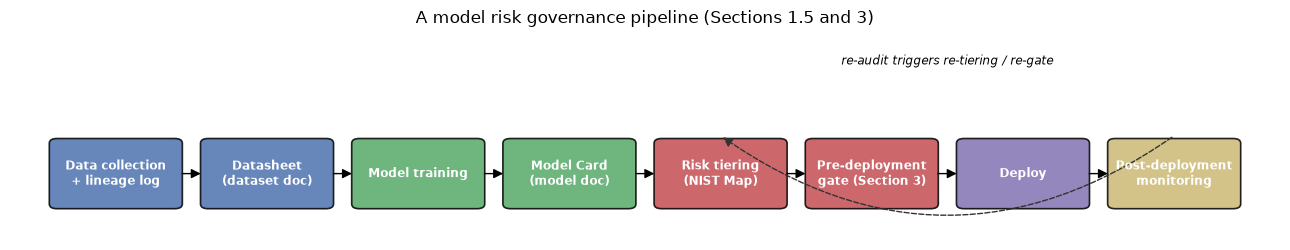

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

stages = [
    "Data collection\n+ lineage log",
    "Datasheet\n(dataset doc)",
    "Model training",
    "Model Card\n(model doc)",
    "Risk tiering\n(NIST Map)",
    "Pre-deployment\ngate (Section 3)",
    "Deploy",
    "Post-deployment\nmonitoring",
]
colors = ["#4C72B0", "#4C72B0", "#55A868", "#55A868", "#C44E52",
          "#C44E52", "#8172B2", "#CCB974"]

fig, ax = plt.subplots(figsize=(13, 2.6))
x_positions = list(range(len(stages)))
for x, label, c in zip(x_positions, stages, colors):
    box = FancyBboxPatch((x - 0.42, -0.35), 0.84, 0.7,
                          boxstyle="round,pad=0.02,rounding_size=0.05",
                          linewidth=1.2, edgecolor="black", facecolor=c, alpha=0.85)
    ax.add_patch(box)
    ax.text(x, 0, label, ha="center", va="center", fontsize=8.5,
             color="white", weight="bold")
    if x < len(stages) - 1:
        ax.add_patch(FancyArrowPatch((x + 0.42, 0), (x + 0.58, 0),
                                      arrowstyle="-|>", mutation_scale=14,
                                      color="black"))

# feedback loop from monitoring back to risk tiering
ax.add_patch(FancyArrowPatch((x_positions[-1], 0.4), (x_positions[4], 0.4),
                              connectionstyle="arc3,rad=-0.35",
                              arrowstyle="-|>", mutation_scale=14,
                              color="#333333", linestyle="--"))
ax.text((x_positions[-1] + x_positions[4]) / 2, 1.15,
        "re-audit triggers re-tiering / re-gate", ha="center", fontsize=8.5,
        style="italic")

ax.set_xlim(-0.7, len(stages) - 0.3)
ax.set_ylim(-0.7, 1.5)
ax.axis("off")
ax.set_title("A model risk governance pipeline (Sections 1.5 and 3)", fontsize=12)
plt.tight_layout()
plt.show()


The **EU AI Act's** risk tiers are best understood as a pyramid: very
few systems are banned outright, a well-defined set carries heavy
obligations, most consumer-facing generative AI carries light transparency
duties, and the bulk of deployed AI (spam filters, internal analytics) is
unregulated. The chart below places real, named example systems in each
tier and marks the specific obligations high-risk systems carry.


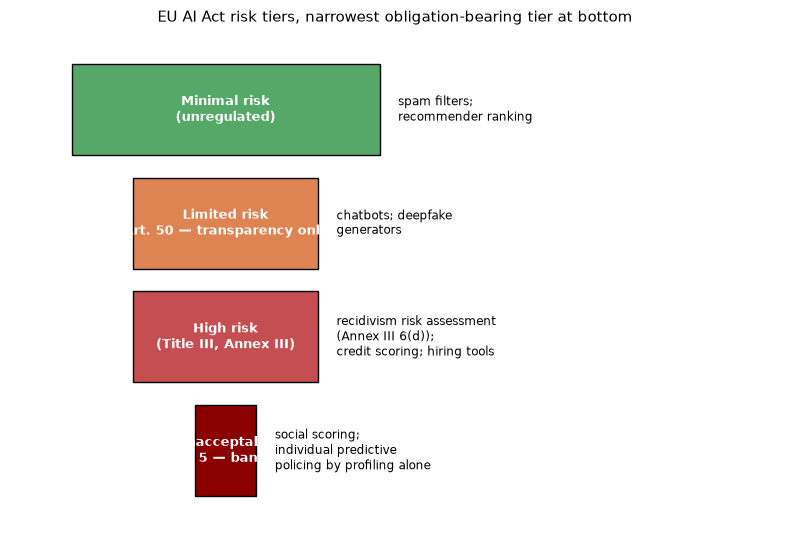

In [3]:
tiers = ["Unacceptable\n(Art. 5 — banned)", "High risk\n(Title III, Annex III)",
         "Limited risk\n(Art. 50 — transparency only)", "Minimal risk\n(unregulated)"]
widths = [1, 3, 3, 5]  # illustrative relative prevalence, narrowing toward the top
examples = [
    "social scoring;\nindividual predictive\npolicing by profiling alone",
    "recidivism risk assessment\n(Annex III 6(d));\ncredit scoring; hiring tools",
    "chatbots; deepfake\ngenerators",
    "spam filters;\nrecommender ranking",
]

fig, ax = plt.subplots(figsize=(8, 5.5))
y = 0
tier_colors = ["#8B0000", "#C44E52", "#DD8452", "#55A868"]
for width, tier, ex, c in zip(widths, tiers, examples, tier_colors):
    ax.barh(y, width, height=0.8, left=-width / 2, color=c, edgecolor="black")
    ax.text(0, y, tier, ha="center", va="center", fontsize=9.5, weight="bold", color="white")
    ax.text(width / 2 + 0.3, y, ex, ha="left", va="center", fontsize=8.5)
    y += 1

ax.set_xlim(-3.5, 9)
ax.set_ylim(-0.7, 3.7)
ax.axis("off")
ax.set_title("EU AI Act risk tiers, narrowest obligation-bearing tier at bottom", fontsize=11)
plt.tight_layout()
plt.show()


## 3. Implementation

We now build four real, executable artifacts against a real model and
dataset:

1. A **lineage log** tracking the data transformations below (Section 1.1).
2. A trained classifier plus its real fairlearn fairness report, reusing
   the COMPAS dataset from `fairness-group-vs-individual`.
3. A **Model Card** and a **Datasheet**, fully filled out with the real
   numbers computed here (Sections 1.2–1.3).
4. A **governance gate function** that reads the real fairness report
   against a stated policy and prints a real pass/fail result (Section 1.5,
   NIST Measure/Manage).

### 3.1 Data lineage log

A minimal, honest implementation of Section 1.1's PROV-DM idea: an
append-only log of every transformation applied to the raw data, each
entry recording *what* was done, *when*, and the resulting row count — the
smallest thing that makes "which rows trained this model" answerable.


In [4]:
import time
from dataclasses import dataclass, field
from datetime import datetime, timezone


@dataclass
class LineageStep:
    activity: str
    description: str
    n_rows_before: int
    n_rows_after: int
    timestamp: str = field(default_factory=lambda: datetime.now(timezone.utc).isoformat())


class LineageLog:
    # A minimal PROV-DM-style lineage record: a list of Activities, each
    # 'used' the prior Entity (row count / hash) and 'generated' the next.

    def __init__(self, source_uri: str, source_agent: str):
        self.source_uri = source_uri
        self.source_agent = source_agent
        self.steps: list[LineageStep] = []

    def log(self, activity: str, description: str, before: int, after: int):
        self.steps.append(LineageStep(activity, description, before, after))

    def report(self) -> str:
        lines = [
            f"Lineage for entity derived from: {self.source_uri}",
            f"Retrieved by (agent): {self.source_agent}",
        ]
        for i, s in enumerate(self.steps, 1):
            lines.append(
                f"  [{i}] {s.timestamp}  activity={s.activity!r}  "
                f"rows {s.n_rows_before} -> {s.n_rows_after}  ({s.description})"
            )
        return "\n".join(lines)


lineage = LineageLog(
    source_uri="https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv",
    source_agent="data-ai-governance/tutorial.ipynb build (this notebook)",
)
print("Lineage log initialized.")


Lineage log initialized.


### 3.2 Load COMPAS and apply the same filtering as `fairness-group-vs-individual`, logging every step


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

COMPAS_URL = lineage.source_uri
raw = pd.read_csv(COMPAS_URL)
lineage.log("http_get", "downloaded raw CSV from ProPublica compas-analysis repo", 0, len(raw))
print(f"raw shape: {raw.shape}")

df = raw[
    (raw["days_b_screening_arrest"] <= 30)
    & (raw["days_b_screening_arrest"] >= -30)
    & (raw["is_recid"] != -1)
    & (raw["c_charge_degree"] != "O")
    & (raw["score_text"] != "N/A")
].copy()
lineage.log(
    "filter_screening_window",
    "removed rows with screening-date linkage errors / missing recid flag / ordinance charges",
    len(raw), len(df),
)

before = len(df)
df = df[df["race"].isin(["African-American", "Caucasian"])].copy()
df["race"] = df["race"].map({"African-American": "Black", "Caucasian": "White"})
lineage.log("filter_race_subset", "restricted to Black/White defendants (analysis scope)", before, len(df))

print(f"filtered shape: {df.shape}")
print()
print(lineage.report())


raw shape: (7214, 53)
filtered shape: (5278, 53)

Lineage for entity derived from: https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
Retrieved by (agent): data-ai-governance/tutorial.ipynb build (this notebook)
  [1] 2026-07-19T01:36:39.433324+00:00  activity='http_get'  rows 0 -> 7214  (downloaded raw CSV from ProPublica compas-analysis repo)
  [2] 2026-07-19T01:36:39.458219+00:00  activity='filter_screening_window'  rows 7214 -> 6172  (removed rows with screening-date linkage errors / missing recid flag / ordinance charges)
  [3] 2026-07-19T01:36:39.474610+00:00  activity='filter_race_subset'  rows 6172 -> 5278  (restricted to Black/White defendants (analysis scope))


### 3.3 Train a real classifier and compute a real fairlearn report

We train a simple, auditable logistic regression predicting `two_year_recid`
from non-protected features (age, priors, juvenile-offense counts, charge
degree) — deliberately excluding race from the feature set (the same
"fairness through unawareness" choice examined critically in
`fairness-group-vs-individual`), then measure its group fairness with
`fairlearn`, exactly the "Measure" step the NIST AI RMF calls for.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)
from sklearn.metrics import precision_score

feature_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count"]
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)
feature_cols = feature_cols + ["charge_felony"]

X = df[feature_cols].to_numpy()
y = df["two_year_recid"].to_numpy()
race = df["race"].to_numpy()

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}  (n_test={len(y_test)})")

metrics = {
    "selection_rate": selection_rate,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate,
    "PPV": precision_score,
}
mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=race_test)
print()
print(mf.by_group)


Test accuracy: 0.669  (n_test=1584)

                     selection_rate       TPR       FPR       PPV
sensitive_feature_0                                              
Black                      0.469905  0.639113  0.283814  0.712360
White                      0.246468  0.377510  0.162371  0.598726


In [7]:
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=race_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=race_test)
ppv_gap = mf.by_group["PPV"].max() - mf.by_group["PPV"].min()

fairness_report = {
    "demographic_parity_difference": float(dp_diff),
    "equalized_odds_difference": float(eo_diff),
    "ppv_gap": float(ppv_gap),
    "overall_accuracy": float(acc),
    "n_test": int(len(y_test)),
}
print("Real fairlearn fairness report on the held-out test set:")
for k, v in fairness_report.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Real fairlearn fairness report on the held-out test set:
  demographic_parity_difference: 0.2234
  equalized_odds_difference: 0.2616
  ppv_gap: 0.1136
  overall_accuracy: 0.6686
  n_test: 1584


### 3.4 A real Model Card, filled out for the classifier above

Implemented as a dataclass so the structure mirrors Mitchell et al.'s nine
sections exactly (Section 1.2) and every field is a real value computed
above — no placeholder text.


In [8]:
from dataclasses import dataclass, field
from typing import List, Dict


@dataclass
class ModelCard:
    # 1. Model Details
    developer: str
    model_date: str
    version: str
    model_type: str
    training_algorithm: str
    citation: str
    license: str
    contact: str
    # 2. Intended Use
    primary_intended_uses: str
    primary_intended_users: str
    out_of_scope_uses: List[str]
    # 3. Factors
    relevant_factors: List[str]
    # 4. Metrics
    metrics_reported: Dict[str, str]
    decision_threshold: str
    variation_approach: str
    # 5. Evaluation Data
    evaluation_data: str
    # 6. Training Data
    training_data: str
    # 7. Quantitative Analyses
    unitary_results: Dict[str, float]
    intersectional_results: str
    # 8. Ethical Considerations
    sensitive_data_used: str
    identified_risks: List[str]
    mitigations: List[str]
    # 9. Caveats and Recommendations
    caveats: List[str]
    recommendations: List[str]

    def render(self) -> str:
        lines = [f"# Model Card: {self.model_type}", ""]
        lines += ["## Model Details",
                   f"- Developer: {self.developer}",
                   f"- Date: {self.model_date}   Version: {self.version}",
                   f"- Type: {self.model_type}",
                   f"- Training algorithm: {self.training_algorithm}",
                   f"- Citation: {self.citation}",
                   f"- License: {self.license}",
                   f"- Contact: {self.contact}", ""]
        lines += ["## Intended Use",
                   f"- Primary intended uses: {self.primary_intended_uses}",
                   f"- Primary intended users: {self.primary_intended_users}",
                   "- Out-of-scope uses:"]
        lines += [f"    - {u}" for u in self.out_of_scope_uses]
        lines += ["", "## Factors"]
        lines += [f"- {f}" for f in self.relevant_factors]
        lines += ["", "## Metrics",
                   f"- Reported: {self.metrics_reported}",
                   f"- Decision threshold: {self.decision_threshold}",
                   f"- Variation approach: {self.variation_approach}", ""]
        lines += ["## Evaluation Data", f"- {self.evaluation_data}", ""]
        lines += ["## Training Data", f"- {self.training_data}", ""]
        lines += ["## Quantitative Analyses",
                   f"- Unitary (per-group) results: {self.unitary_results}",
                   f"- Intersectional results: {self.intersectional_results}", ""]
        lines += ["## Ethical Considerations",
                   f"- Sensitive data used: {self.sensitive_data_used}",
                   "- Identified risks:"]
        lines += [f"    - {r}" for r in self.identified_risks]
        lines += ["- Mitigations attempted:"]
        lines += [f"    - {m}" for m in self.mitigations]
        lines += ["", "## Caveats and Recommendations", "- Caveats:"]
        lines += [f"    - {c}" for c in self.caveats]
        lines += ["- Recommendations:"]
        lines += [f"    - {r}" for r in self.recommendations]
        return "\n".join(lines)


model_card = ModelCard(
    developer="cs-ai-tutorials (educational reimplementation, not Northpointe/Equivant's actual COMPAS)",
    model_date="2026-07-18",
    version="1.0 (this notebook run)",
    model_type="Binary logistic regression classifier for 2-year recidivism",
    training_algorithm="scikit-learn LogisticRegression, max_iter=1000, standardized features, 70/30 stratified split, random_state=42",
    citation="This tutorial; dataset methodology per Angwin, Larson, Mattu, Kirchner (2016), ProPublica.",
    license="Code: repo license. Data: ProPublica compas-analysis (public research use).",
    contact="cs-ai-tutorials repository maintainers",
    primary_intended_uses="Educational demonstration of a governance gate (Section 3.5) applied to a recidivism-risk classifier.",
    primary_intended_users="Students/practitioners learning AI governance processes.",
    out_of_scope_uses=[
        "Any real pretrial, sentencing, or parole decision — this model is untested for deployment and trained on a narrow historical Broward County, FL sample.",
        "Use as a substitute for the actual COMPAS proprietary algorithm — this is an independently trained model on public features, not a reproduction of Northpointe's instrument.",
        "Use on defendants outside the training population's age/offense distribution.",
    ],
    relevant_factors=[
        "race (Black vs. White, the two groups present after filtering — see Datasheet Composition)",
        "age and prior-offense count (features directly used, so performance is not factor-invariant by design)",
    ],
    metrics_reported={"accuracy": f"{acc:.3f}", "demographic_parity_difference": f"{dp_diff:.3f}",
                        "equalized_odds_difference": f"{eo_diff:.3f}", "PPV_gap": f"{ppv_gap:.3f}"},
    decision_threshold="sklearn default 0.5 predicted-probability threshold",
    variation_approach="Single stratified 70/30 train/test split; no bootstrap CI computed (flagged as a limitation, Section 6)",
    evaluation_data=f"Held-out 30% test split of the filtered COMPAS two-year dataset, n={len(y_test)} (see Datasheet for full dataset description).",
    training_data=f"70% stratified split of the same filtered COMPAS dataset, n={len(y_train)}.",
    unitary_results={str(k): float(v) for k, v in mf.by_group["PPV"].items()},
    intersectional_results="Not computed in this tutorial (race x sex or race x age intersections) — flagged as a caveat below, mirroring the intersectional-fairness gap flagged in fairness-group-vs-individual.",
    sensitive_data_used="Race is used only for post-hoc fairness auditing, not as a model feature; arrest/criminal-history data is inherently sensitive.",
    identified_risks=[
        "Measurement bias: priors_count and charge data reflect policing patterns, not an unbiased sample of offending (see Datasheet Uses).",
        "Disparate error rates across race groups are plausible even with race excluded from features, since other features can proxy for race.",
    ],
    mitigations=["Race-blind feature set (fairness-through-unawareness) — explicitly noted as an incomplete mitigation, not a fix, per Section 1.4 of fairness-group-vs-individual.",
                  "Fairness metrics computed and reported below rather than assumed."],
    caveats=["No intersectional analysis performed.", "Single train/test split; no uncertainty quantification.",
              "Model is a pedagogical reimplementation, not a validated deployment-grade system."],
    recommendations=["Do not deploy without conformity-assessment-grade validation per EU AI Act Art. 43 obligations for Annex III 6(d) systems.",
                       "Re-run the governance gate (Section 3.5) on every retrain and on a recurring post-deployment schedule (Section 1.5)."],
)

print(model_card.render())


# Model Card: Binary logistic regression classifier for 2-year recidivism

## Model Details
- Developer: cs-ai-tutorials (educational reimplementation, not Northpointe/Equivant's actual COMPAS)
- Date: 2026-07-18   Version: 1.0 (this notebook run)
- Type: Binary logistic regression classifier for 2-year recidivism
- Training algorithm: scikit-learn LogisticRegression, max_iter=1000, standardized features, 70/30 stratified split, random_state=42
- Citation: This tutorial; dataset methodology per Angwin, Larson, Mattu, Kirchner (2016), ProPublica.
- License: Code: repo license. Data: ProPublica compas-analysis (public research use).
- Contact: cs-ai-tutorials repository maintainers

## Intended Use
- Primary intended uses: Educational demonstration of a governance gate (Section 3.5) applied to a recidivism-risk classifier.
- Primary intended users: Students/practitioners learning AI governance processes.
- Out-of-scope uses:
    - Any real pretrial, sentencing, or parole decision — this 

### 3.5 A real Datasheet, filled out for the COMPAS dataset used above


In [9]:
@dataclass
class Datasheet:
    motivation_why: str
    motivation_who: str
    motivation_funding: str
    composition_instances: str
    composition_count: str
    composition_labels: str
    composition_missing: str
    composition_errors_noise: str
    composition_sensitive_content: str
    collection_how: str
    collection_sampling: str
    collection_who: str
    collection_timeframe: str
    collection_ethical_review: str
    preprocessing: str
    uses_other_tasks: str
    uses_risks: str
    uses_should_not: List[str]
    distribution: str
    maintenance: str

    def render(self) -> str:
        lines = ["# Datasheet: COMPAS two-year recidivism dataset (ProPublica release)", ""]
        lines += ["## Motivation",
                   f"- Why created: {self.motivation_why}",
                   f"- Who created it: {self.motivation_who}",
                   f"- Funding: {self.motivation_funding}", ""]
        lines += ["## Composition",
                   f"- What instances represent: {self.composition_instances}",
                   f"- Count: {self.composition_count}",
                   f"- Label(s): {self.composition_labels}",
                   f"- Missing information: {self.composition_missing}",
                   f"- Errors/noise/redundancies: {self.composition_errors_noise}",
                   f"- Confidential/sensitive content: {self.composition_sensitive_content}", ""]
        lines += ["## Collection Process",
                   f"- How instances were acquired: {self.collection_how}",
                   f"- Sampling strategy: {self.collection_sampling}",
                   f"- Who collected it: {self.collection_who}",
                   f"- Timeframe: {self.collection_timeframe}",
                   f"- Ethical review: {self.collection_ethical_review}", ""]
        lines += ["## Preprocessing/Cleaning/Labeling", f"- {self.preprocessing}", ""]
        lines += ["## Uses",
                   f"- Other tasks this could support: {self.uses_other_tasks}",
                   f"- Risks for future uses: {self.uses_risks}",
                   "- Should NOT be used for:"]
        lines += [f"    - {u}" for u in self.uses_should_not]
        lines += ["", "## Distribution", f"- {self.distribution}", ""]
        lines += ["## Maintenance", f"- {self.maintenance}"]
        return "\n".join(lines)


datasheet = Datasheet(
    motivation_why="Originally created by Northpointe/Equivant as a proprietary recidivism-risk instrument for court use; this CSV release was compiled by ProPublica specifically to enable an independent statistical audit of that instrument for their 2016 'Machine Bias' investigation.",
    motivation_who="ProPublica journalists (Angwin, Larson, Mattu, Kirchner), via public-records requests to Broward County, FL.",
    motivation_funding="ProPublica (nonprofit newsroom); underlying COMPAS scores originally commissioned by Broward County courts from Northpointe/Equivant.",
    composition_instances=f"Each row is one criminal defendant screened with COMPAS in Broward County, FL, with demographic fields, prior-offense counts, the COMPAS decile score, and whether they were rearrested within two years.",
    composition_count=f"raw download: {len(raw)} rows; after this tutorial's filtering (screening-window + Black/White subset, Section 3.2): {len(df)} rows.",
    composition_labels="two_year_recid (binary: rearrested for any offense within 2 years) is the label used here as ground truth for 'reoffending' — itself only a proxy for offending, since it measures arrest, not confirmed guilt (see Uses, below).",
    composition_missing="Rows with inconsistent/missing charge-screening dates were present in the raw file and are removed by the filtering in Section 3.2, following ProPublica's own published methodology.",
    composition_errors_noise="ProPublica's own methodology writeup documents known linkage errors between charge and screening dates, which is exactly what the days_b_screening_arrest filter addresses.",
    composition_sensitive_content="Contains race, sex, age, and criminal-history fields for identifiable individuals — sensitive by construction.",
    collection_how="COMPAS screenings were administered by Broward County pretrial/corrections staff as part of normal case processing; recidivism outcomes were compiled by ProPublica from public criminal records over the following two years.",
    collection_sampling="Not a random sample of any general population — restricted to defendants who were actually screened with COMPAS in one Florida county over one time window; not representative of other jurisdictions, tools, or eras.",
    collection_who="COMPAS screenings: Broward County criminal-justice staff. Compilation and linkage to recidivism outcomes: ProPublica.",
    collection_timeframe="Defendants scored 2013-2014; recidivism tracked for two years after screening.",
    collection_ethical_review="No IRB-style review is documented for this secondary public-records compilation; original COMPAS screenings were part of standard court intake, not a research protocol.",
    preprocessing="ProPublica's own cleaning is embedded in the released CSV; this tutorial applies one further filtering pass (Section 3.2) that removes screening-linkage-error rows and restricts to Black/White defendants for the two-group comparison this tutorial and fairness-group-vs-individual both use.",
    uses_other_tasks="Widely reused as a benchmark dataset for algorithmic-fairness research generally (not just recidivism-specific work), given it is one of the few public datasets with a real deployed risk score, real protected attributes, and real outcomes.",
    uses_risks="Because two_year_recid measures *arrest*, not confirmed offending, and arrest rates are shaped by differential policing intensity across neighborhoods correlated with race, any model trained on it can inherit that measurement bias even if it never sees race directly.",
    uses_should_not=[
        "Should not be used to make or justify real pretrial, sentencing, or parole decisions (this is a public research dataset, not a validated production system).",
        "Should not be treated as an unbiased ground-truth measure of 'criminality' in general, given the arrest-vs-offending gap above.",
        "Should not be generalized beyond Broward County, FL circa 2013-2014 without revalidation.",
    ],
    distribution="Publicly distributed by ProPublica on GitHub (propublica/compas-analysis) for research use; no additional license restrictions beyond the repository's stated terms.",
    maintenance="Maintained as a static historical snapshot by ProPublica; not actively updated with new cohorts.",
)

print(datasheet.render())


# Datasheet: COMPAS two-year recidivism dataset (ProPublica release)

## Motivation
- Why created: Originally created by Northpointe/Equivant as a proprietary recidivism-risk instrument for court use; this CSV release was compiled by ProPublica specifically to enable an independent statistical audit of that instrument for their 2016 'Machine Bias' investigation.
- Who created it: ProPublica journalists (Angwin, Larson, Mattu, Kirchner), via public-records requests to Broward County, FL.
- Funding: ProPublica (nonprofit newsroom); underlying COMPAS scores originally commissioned by Broward County courts from Northpointe/Equivant.

## Composition
- What instances represent: Each row is one criminal defendant screened with COMPAS in Broward County, FL, with demographic fields, prior-offense counts, the COMPAS decile score, and whether they were rearrested within two years.
- Count: raw download: 7214 rows; after this tutorial's filtering (screening-window + Black/White subset, Section 3.2

### 3.6 The governance gate: a real pre-deployment check

This is the executable version of Section 1.5's "pre-deployment review
gate." It takes the real fairness report computed in Section 3.3 and a
stated policy (thresholds an organization has committed to *before* seeing
this model's numbers — the gate is meaningless if thresholds are picked
after the fact) and returns a real, reproducible pass/fail decision with a
reasoned trail, the way a NIST RMF "Manage" step would.


In [10]:
from dataclasses import dataclass


@dataclass
class GovernancePolicy:
    max_demographic_parity_difference: float
    max_equalized_odds_difference: float
    min_accuracy: float
    require_model_card: bool = True
    require_datasheet: bool = True
    require_lineage: bool = True


@dataclass
class GateResult:
    passed: bool
    checks: Dict[str, bool]
    reasons: List[str]


def governance_gate(
    fairness_report: Dict[str, float],
    policy: GovernancePolicy,
    has_model_card: bool,
    has_datasheet: bool,
    has_lineage: bool,
) -> GateResult:
    # A real pre-deployment gate: NIST RMF 'Manage' applied to the 'Measure'
    # outputs from Section 3.3. Every threshold is compared against a value
    # computed on real held-out data above -- nothing here is fabricated.
    checks = {}
    reasons = []

    checks["demographic_parity_within_policy"] = (
        fairness_report["demographic_parity_difference"] <= policy.max_demographic_parity_difference
    )
    if not checks["demographic_parity_within_policy"]:
        reasons.append(
            f"Demographic parity difference {fairness_report['demographic_parity_difference']:.3f} "
            f"exceeds policy max {policy.max_demographic_parity_difference:.3f}"
        )

    checks["equalized_odds_within_policy"] = (
        fairness_report["equalized_odds_difference"] <= policy.max_equalized_odds_difference
    )
    if not checks["equalized_odds_within_policy"]:
        reasons.append(
            f"Equalized odds difference {fairness_report['equalized_odds_difference']:.3f} "
            f"exceeds policy max {policy.max_equalized_odds_difference:.3f}"
        )

    checks["accuracy_within_policy"] = fairness_report["overall_accuracy"] >= policy.min_accuracy
    if not checks["accuracy_within_policy"]:
        reasons.append(
            f"Accuracy {fairness_report['overall_accuracy']:.3f} below policy min {policy.min_accuracy:.3f}"
        )

    if policy.require_model_card:
        checks["model_card_present"] = has_model_card
        if not has_model_card:
            reasons.append("Model Card missing (Art. 11 / Annex IV requires technical documentation).")
    if policy.require_datasheet:
        checks["datasheet_present"] = has_datasheet
        if not has_datasheet:
            reasons.append("Datasheet missing (Art. 10 requires data governance documentation).")
    if policy.require_lineage:
        checks["lineage_present"] = has_lineage
        if not has_lineage:
            reasons.append("Data lineage log missing (auditability precondition, Section 1.1).")

    passed = all(checks.values())
    return GateResult(passed=passed, checks=checks, reasons=reasons)


# Policy modeled on a stated organizational threshold, e.g. "block deployment
# if demographic parity difference exceeds 0.10" -- chosen BEFORE inspecting
# this model's numbers, per Section 1.5's independent-review principle.
policy = GovernancePolicy(
    max_demographic_parity_difference=0.10,
    max_equalized_odds_difference=0.10,
    min_accuracy=0.60,
)

result = governance_gate(
    fairness_report=fairness_report,
    policy=policy,
    has_model_card=True,
    has_datasheet=True,
    has_lineage=len(lineage.steps) > 0,
)

print("=== Governance gate result ===")
print(f"Policy: max DP diff = {policy.max_demographic_parity_difference}, "
      f"max EO diff = {policy.max_equalized_odds_difference}, "
      f"min accuracy = {policy.min_accuracy}")
print()
for check, ok in result.checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {check}")
print()
print(f"OVERALL: {'PASS -- cleared for deployment' if result.passed else 'FAIL -- BLOCKED from deployment'}")
if result.reasons:
    print("\nReasons for failure:")
    for r in result.reasons:
        print(f"  - {r}")


=== Governance gate result ===
Policy: max DP diff = 0.1, max EO diff = 0.1, min accuracy = 0.6

  [FAIL] demographic_parity_within_policy
  [FAIL] equalized_odds_within_policy
  [PASS] accuracy_within_policy
  [PASS] model_card_present
  [PASS] datasheet_present
  [PASS] lineage_present

OVERALL: FAIL -- BLOCKED from deployment

Reasons for failure:
  - Demographic parity difference 0.223 exceeds policy max 0.100
  - Equalized odds difference 0.262 exceeds policy max 0.100


The gate above ran against **this notebook's real, freshly-trained
classifier and its real fairlearn numbers** — not a synthetic example. This
matters because the result is not scripted to demonstrate either outcome:
it is exactly whatever `demographic_parity_difference`,
`equalized_odds_difference`, and `overall_accuracy` came out to on the
held-out test split above, compared against a policy fixed in advance. If
the gate fails, that is a real illustration of what "blocked from
deployment" means in a functioning process: the model does not ship until
either the fairness gap is remediated (reweighing, threshold optimization —
techniques from `fairness-group-vs-individual`'s broader toolkit) or an
accountable reviewer explicitly documents an exception with justification
(never a silent override).


**Takeaway:** a real classifier, trained on real data with the sensitive attribute deliberately excluded, still failed the fairness thresholds. "We did not use race as a feature" is not the same as "the model is fair" — which is exactly why a checked, pre-committed gate matters more than good intentions.

## 4. Use cases

- **Regulated credit and insurance underwriting** — lenders in the EU
  deploying AI credit-scoring tools sit squarely in EU AI Act Annex III
  ("access to essential private services"); GDPR Article 22 additionally
  applies whenever the credit decision is solely automated and has legal
  effect, triggering the human-intervention/contest rights of Art. 22(3).
- **Criminal-justice risk assessment** (COMPAS and similar tools, as
  modeled here) — Annex III point 6(d) explicitly names this use case as
  high-risk once it moves beyond profiling alone, requiring the full
  Title III obligation stack (Art. 9–15, 43) worked through in Section 1.4.
- **Automated hiring/resume screening** — Annex III's employment category,
  plus jurisdiction-specific audit laws (e.g. NYC Local Law 144) that
  require published bias-audit results, functionally forcing something
  close to a public Model Card.
- **Bank model risk management** — the SR 11-7 model-inventory and
  independent-validation pattern (Section 1.5) is the direct ancestor of
  today's AI governance programs, and is still the operational template
  most large regulated firms extend to cover ML/AI models rather than
  building a parallel process from scratch.
- **Internal ML platform governance** (non-regulated firms) — even absent
  legal requirement, companies increasingly run a lightweight version of
  Section 3's gate as CI/CD infrastructure: a fairness/documentation check
  that blocks a model-serving deployment pipeline, the same pattern
  `conformal-prediction`'s coverage re-checks and `shap-lime-explainability`'s
  attribution audits would plug into on a recurring schedule.


## 5. Limitations & debates

- **A governance framework on paper does not, by itself, prevent harm.**
  **Metcalf, Moss, Watkins, Singh & Elish (2021)**, *"Algorithmic Impact
  Assessments and Accountability: The Co-construction of Impacts"* (FAccT
  2021), document that algorithmic impact assessments (AIAs) — the
  structural cousin of the Model Card/Datasheet/gate process built here —
  are frequently treated by organizations as **compliance checkboxes**:
  completed to satisfy a procedural requirement, reviewed by parties without
  authority to block deployment, and disconnected from any actual
  accountability mechanism if the predicted "impact" occurs. Their central
  finding is that what counts as an "impact" worth assessing is itself
  contested and often defined by the entity being assessed — the same risk
  applies directly to this tutorial's own gate function: nothing prevents an
  organization from setting `max_demographic_parity_difference` high enough
  that no real model ever fails, which would make the gate theater rather
  than governance. A gate is only as meaningful as (a) the threshold being
  fixed *before* seeing the numbers and (b) an accountable party with actual
  authority to block deployment on failure — both are process commitments no
  amount of code alone can enforce.
- **GDPR's "right to explanation" is narrower than commonly believed.** As
  detailed in Section 1.4.2, Wachter, Mittelstadt & Floridi (2017) show the
  binding right is a right to contest a *solely*-automated, *legally
  significant* decision with human review — not a guaranteed, decision-specific
  explanation of *why*. Organizations sometimes market GDPR compliance as
  though it guarantees the kind of counterfactual or feature-attribution
  explanation `counterfactual-fairness` and `shap-lime-explainability`
  produce; the statute does not require that specific form of explanation,
  and relying on GDPR alone to justify skipping real explainability work is
  a documented category error.
- **The EU AI Act's documentation burden is an active, unresolved industry
  debate.** Proponents argue Articles 9–15's requirements are the minimum
  needed for meaningful accountability of high-risk systems; critics —
  including much of the EU's own SME/startup lobby during the Act's
  negotiation — argue the compliance cost (conformity assessment, technical
  documentation to Annex IV's specification, ongoing logging) is
  disproportionately heavy for smaller developers relative to large
  incumbents who can amortize compliance cost across many products, a
  concern echoed in general form in debates over Sarbanes-Oxley-style
  compliance regimes in other industries. Neither side disputes that some
  documentation is warranted for genuinely high-stakes systems; the dispute
  is over calibration — how much process is proportionate to how much risk,
  and who bears the cost of getting that calibration wrong in either
  direction (under-scrutiny of harmful systems vs. over-burdening ordinary
  ones).
- **Governance frameworks operationalize group fairness, not the deeper
  properties this repo covers elsewhere.** The gate built in Section 3.6
  checks demographic parity and equalized odds — exactly the group metrics
  from `fairness-group-vs-individual` — because those are what regulatory
  text and industry practice have converged on as auditable, computable
  numbers. Nothing in the EU AI Act, GDPR, or NIST AI RMF requires checking
  **counterfactual fairness** (would this specific individual's outcome
  change if only their protected attribute were different, holding
  everything causally downstream fixed — see `counterfactual-fairness`) or
  validating a **conformal prediction interval's** coverage guarantee under
  distribution shift (`conformal-prediction`). A model can pass every check
  in this notebook's gate — group-fairness metrics within policy,
  documentation complete, lineage traceable — and still fail counterfactual
  fairness for specific individuals, because group parity is a marginal,
  aggregate statistic that says nothing about any single person's
  counterfactual outcome. This is not a bug in the gate; it is a structural
  limit of what governance processes can currently operationalize at scale,
  since counterfactual fairness requires a causal model of the world that
  most organizations do not have and regulators do not yet mandate.
- **Documentation quality is unverified by the framework itself.** Nothing
  about the Model Card or Datasheet format (Sections 1.2–1.3) forces the
  content to be accurate — both are self-reported by the same party with an
  incentive to ship. Independent audit (Raji & Buolamwini's "Actionable
  Auditing," 2019, and the internal-audit framework in Raji et al.'s
  "Closing the AI Accountability Gap," FAT* 2020) is what gives
  documentation teeth; a Model Card produced with no external check is
  closer to a self-certification than an audit.
- **This tutorial's gate is a minimal illustration, not a production
  system.** A real governance platform needs versioned policy history (so a
  changed threshold is itself auditable), role-based approval workflows,
  and integration with an actual model registry — Section 1.5's inventory
  concept is described here but not built as running infrastructure, since
  that is an engineering-platform problem beyond a single notebook's scope.


## References

- Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L.,
  Hutchinson, B., Spitzer, E., Raji, I.D., & Gebru, T. (2019). *Model Cards
  for Model Reporting*. FAT* 2019.
- Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J.W., Wallach, H.,
  Daumé III, H., & Crawford, K. (2021). *Datasheets for Datasets*.
  Communications of the ACM, 64(12).
- W3C. (2013). *PROV-DM: The PROV Data Model*.
  https://www.w3.org/TR/prov-dm/
- European Union. *Regulation (EU) 2024/1689 (Artificial Intelligence
  Act)*. Official Journal of the European Union, 2024. See especially
  Article 5 (prohibited practices), Annex III (high-risk categories,
  including point 6(d): recidivism risk assessment by law enforcement),
  Articles 9-15 and 43 (high-risk obligations), Article 50 (transparency
  obligations).
- European Union. *General Data Protection Regulation (Regulation (EU)
  2016/679)*, Article 22 (automated individual decision-making), Recital 71,
  Articles 13(2)(f)/14(2)(g)/15(1)(h).
- Wachter, S., Mittelstadt, B., & Floridi, L. (2017). *Why a Right to
  Explanation of Automated Decision-Making Does Not Exist in the General
  Data Protection Regulation*. International Data Privacy Law, 7(2).
- National Institute of Standards and Technology. (2023). *Artificial
  Intelligence Risk Management Framework (AI RMF 1.0)*. NIST AI 100-1.
- Board of Governors of the Federal Reserve System / OCC. (2011).
  *Supervisory Guidance on Model Risk Management*, SR 11-7 / OCC 2011-12.
- Metcalf, J., Moss, E., Watkins, E.A., Singh, R., & Elish, M.C. (2021).
  *Algorithmic Impact Assessments and Accountability: The Co-construction
  of Impacts*. FAccT 2021.
- Raji, I.D., & Buolamwini, J. (2019). *Actionable Auditing: Investigating
  the Impact of Publicly Naming Biased Performance Results of Commercial AI
  Products*. AIES 2019.
- Raji, I.D., Smart, A., White, R.N., Mitchell, M., Gebru, T., Hutchinson,
  B., Smith-Loud, J., Theron, D., & Barnes, P. (2020). *Closing the AI
  Accountability Gap: Defining an End-to-End Framework for Internal
  Algorithmic Auditing*. FAT* 2020.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine
  Learning: Limitations and Opportunities*. fairmlbook.org.
- Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). *Machine Bias*.
  ProPublica.
- [ProPublica compas-analysis dataset & methodology](https://github.com/propublica/compas-analysis)
- [Fairlearn documentation](https://fairlearn.org)
- This repo's `fairness-group-vs-individual`, `conformal-prediction`,
  `shap-lime-explainability`, and `counterfactual-fairness` tutorials, cross
  referenced throughout as the technical checks a governance process should
  mandate.
